In [41]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl plotly -q

In [42]:
import requests
import zipfile
import io
import os

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("data")

print("Dataset downloaded successfully!")
print(os.listdir("data"))

Dataset downloaded successfully!
['Online Retail.xlsx']


In [43]:
import pandas as pd
import numpy as np

file_path = "data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [45]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [46]:
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [47]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 5268


In [48]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Identify cancelled invoices
df["IsCancellation"] = df["InvoiceNo"].astype(str).str.startswith("C")

print("Cancellation transactions:", df["IsCancellation"].sum())

Cancellation transactions: 9288


In [49]:
clean = df.copy()

# Remove duplicates
clean = clean.drop_duplicates()

# Remove invalid rows
clean = clean.dropna(subset=["InvoiceDate", "Description"])

# Remove cancelled transactions
clean = clean[~clean["IsCancellation"]]

# Remove invalid quantity and price
clean = clean[
    (clean["Quantity"] > 0) &
    (clean["UnitPrice"] > 0)
]

# Calculate revenue
clean["Amount"] = clean["Quantity"] * clean["UnitPrice"]

print("Original rows:", len(df))
print("Clean rows:", len(clean))
print("Rows removed:", len(df) - len(clean))

Original rows: 541909
Clean rows: 524878
Rows removed: 17031


In [50]:
print("Total Revenue: £", round(clean["Amount"].sum(), 2))
print("Number of Orders:", clean["InvoiceNo"].nunique())
print("Number of Customers:", clean["CustomerID"].nunique())
print("Number of Products:", clean["StockCode"].nunique())
print("Number of Countries:", clean["Country"].nunique())

Total Revenue: £ 10642110.8
Number of Orders: 19960
Number of Customers: 4338
Number of Products: 3922
Number of Countries: 38


In [51]:
daily_sales = (
    clean.groupby(clean["InvoiceDate"].dt.date)["Amount"]
    .sum()
    .reset_index()
)

daily_sales.columns = ["Date", "Revenue"]

daily_sales.head()

,Date,Revenue
0,2010-12-01,58776.79
1,2010-12-02,47629.42
2,2010-12-03,46898.63
3,2010-12-05,31364.63
4,2010-12-06,54624.15


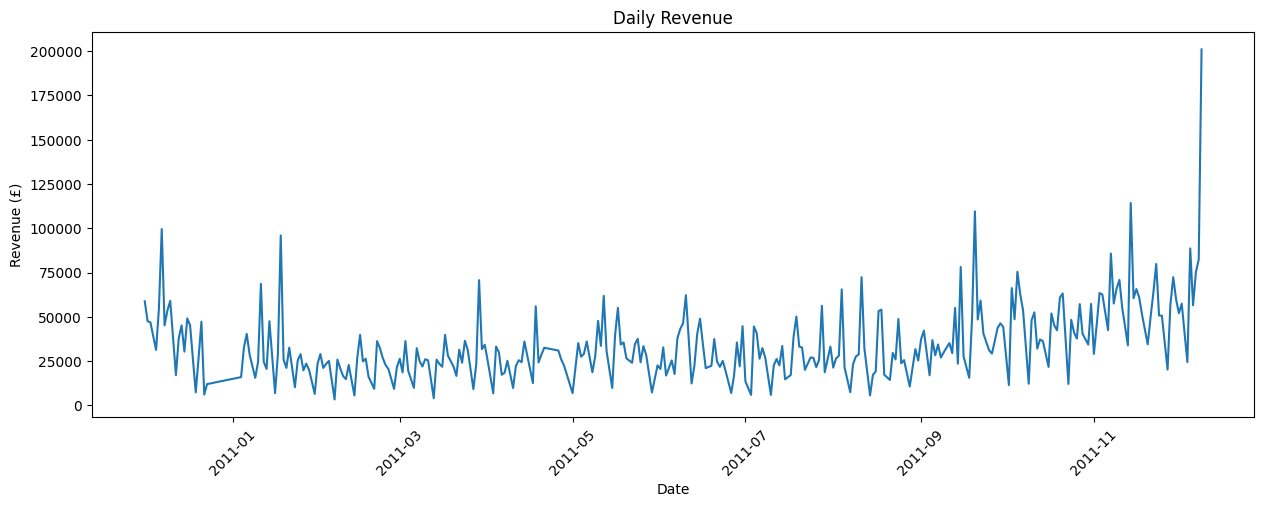

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Revenue"]
)

plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

In [53]:
top_products = (
    clean.groupby("Description")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Amount
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


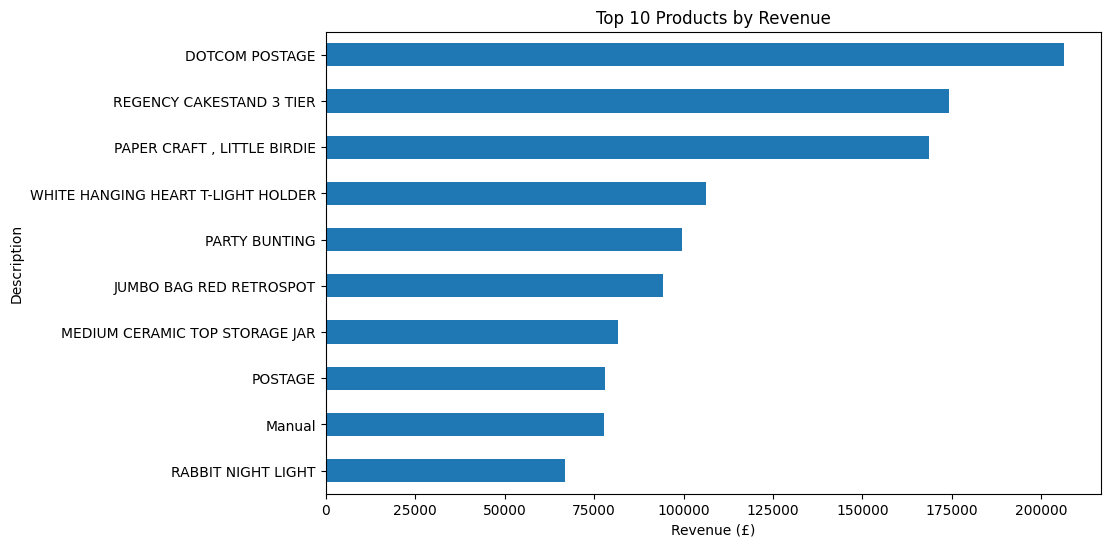

In [54]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")

plt.show()

In [55]:
country_sales = (
    clean.groupby("Country")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

,Amount
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


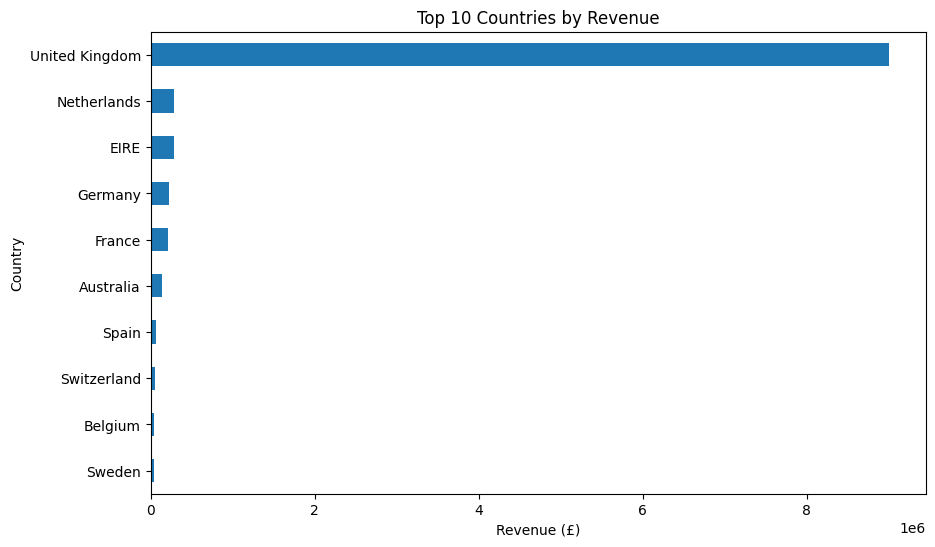

In [56]:
plt.figure(figsize=(10,6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")

plt.show()

In [57]:
country_sales = (
    clean.groupby("Country")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

,Amount
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


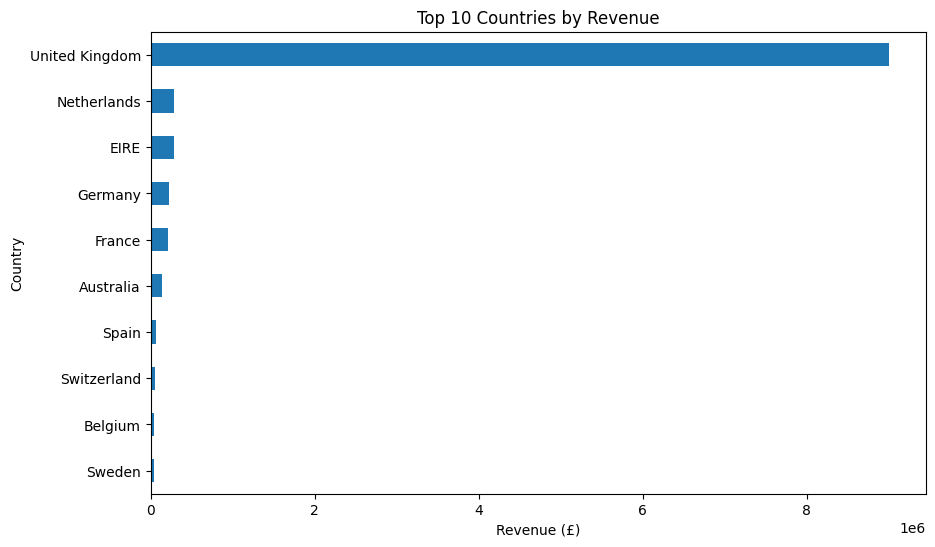

In [58]:
plt.figure(figsize=(10,6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")

plt.show()

In [59]:
correlation = clean[
    ["Quantity", "UnitPrice", "Amount"]
].corr(method="spearman")

correlation

,Quantity,UnitPrice,Amount
Quantity,1.000000,-0.408682,0.673648
UnitPrice,-0.408682,1.000000,0.335754
Amount,0.673648,0.335754,1.000000


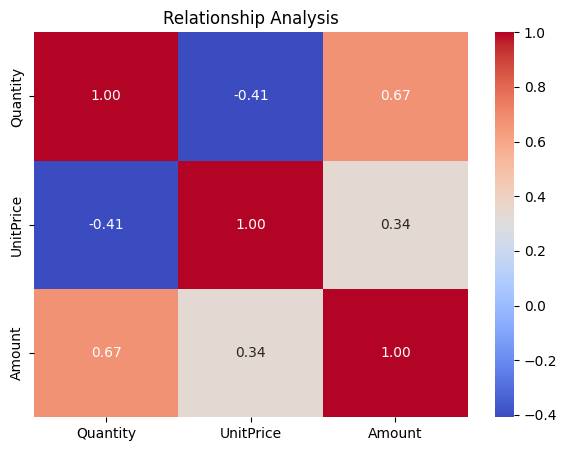

In [60]:
import seaborn as sns

plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Relationship Analysis")

plt.show()

In [61]:
rho = clean[["Quantity", "UnitPrice"]].corr(
    method="spearman"
).iloc[0, 1]

print("Spearman correlation:", round(rho, 3))

Spearman correlation: -0.409


In [62]:
quantity_cutoff = clean["Quantity"].quantile(0.90)

high_quantity = clean[
    clean["Quantity"] >= quantity_cutoff
]

normal_quantity = clean[
    clean["Quantity"] < quantity_cutoff
]

print(
    "Median price - top 10% quantity:",
    round(high_quantity["UnitPrice"].median(), 2)
)

print(
    "Median price - remaining:",
    round(normal_quantity["UnitPrice"].median(), 2)
)

Median price - top 10% quantity: 0.85
Median price - remaining: 2.46


In [63]:
customer_data = clean.dropna(subset=["CustomerID"]).copy()

snapshot_date = customer_data["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = customer_data.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (snapshot_date - x.max()).days
    ),
    Frequency=(
        "InvoiceNo",
        "nunique"
    ),
    Monetary=(
        "Amount",
        "sum"
    )
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [64]:
rfm["R"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4,3,2,1]
).astype(int)

rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
).astype(int)

rfm["M"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1,2,3,4]
).astype(int)

In [65]:
def segment(row):

    if row["R"] >= 3 and row["F"] >= 3 and row["M"] >= 3:
        return "Champions"

    elif row["R"] >= 3 and row["F"] >= 2:
        return "Loyal / Active"

    elif row["R"] <= 2 and row["F"] >= 3:
        return "At Risk"

    elif row["R"] <= 2 and row["F"] <= 2:
        return "Hibernating"

    else:
        return "Potential"


rfm["Segment"] = rfm.apply(segment, axis=1)

rfm.head(20)

,CustomerID,Recency,Frequency,Monetary,R,F,M,Segment
0,12346.0,326,1,77183.60,1,1,4,Hibernating
1,12347.0,2,7,4310.00,4,4,4,Champions
2,12348.0,75,4,1797.24,2,3,4,At Risk
3,12349.0,19,1,1757.55,3,1,4,Potential
4,12350.0,310,1,334.40,1,1,2,Hibernating
5,12352.0,36,8,2506.04,3,4,4,Champions
6,12353.0,204,1,89.00,1,1,1,Hibernating
7,12354.0,232,1,1079.40,1,1,3,Hibernating
8,12355.0,214,1,459.40,1,1,2,Hibernating
9,12356.0,23,3,2811.43,3,3,4,Champions


In [66]:
segment_counts = rfm["Segment"].value_counts()

segment_counts

,count
Segment,
Hibernating,1514
Champions,1312
At Risk,655
Loyal / Active,604
Potential,253


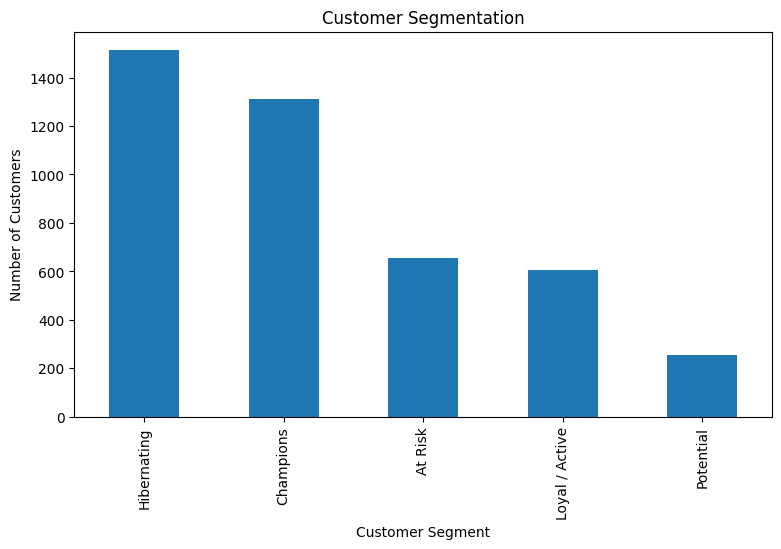

In [67]:
plt.figure(figsize=(9,5))

segment_counts.plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

In [68]:
from sklearn.ensemble import IsolationForest

In [69]:
anomaly_data = clean[
    ["Quantity", "UnitPrice", "Amount"]
].copy()

anomaly_data["LogQuantity"] = np.log1p(
    anomaly_data["Quantity"]
)

anomaly_data["LogAmount"] = np.log1p(
    anomaly_data["Amount"]
)

In [70]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

X = anomaly_data[
    ["LogQuantity", "UnitPrice", "LogAmount"]
]

anomaly_data["Prediction"] = model.fit_predict(X)

In [71]:
anomalies = anomaly_data[
    anomaly_data["Prediction"] == -1
]

print("Number of anomalies:", len(anomalies))

anomalies.sort_values(
    "Amount",
    ascending=False
).head(20)

Number of anomalies: 5245


,Quantity,UnitPrice,Amount,LogQuantity,LogAmount,Prediction
540421,80995,2.08,168469.60,11.302155,12.034517,-1
61619,74215,1.04,77183.60,11.214735,11.253955,-1
222680,60,649.50,38970.00,4.110874,10.570573,-1
15017,1,13541.33,13541.33,0.693147,9.513576,-1
299982,1,11062.06,11062.06,0.693147,9.311367,-1
173382,1,8142.75,8142.75,0.693147,9.005006,-1
348325,1412,5.06,7144.72,7.253470,8.874269,-1
160546,3114,2.10,6539.40,8.043984,8.785754,-1
52711,3114,2.10,6539.40,8.043984,8.785754,-1
421601,2400,2.08,4992.00,7.783641,8.515792,-1


In [72]:
daily = (
    clean.groupby(
        clean["InvoiceDate"].dt.floor("D")
    )
    .agg(
        Revenue=("Amount", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

daily.columns = ["Date", "Revenue", "Orders"]

daily = daily.sort_values("Date")

daily.head()

,Date,Revenue,Orders
0,2010-12-01,58776.79,127
1,2010-12-02,47629.42,142
2,2010-12-03,46898.63,68
3,2010-12-05,31364.63,88
4,2010-12-06,54624.15,102


In [73]:
daily["lag1"] = daily["Revenue"].shift(1)

daily["lag7"] = daily["Revenue"].shift(7)

daily["rolling7"] = (
    daily["Revenue"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily["dayofweek"] = daily["Date"].dt.dayofweek

daily["month"] = daily["Date"].dt.month

daily = daily.dropna()

daily.head()

,Date,Revenue,Orders,lag1,lag7,rolling7,dayofweek,month
7,2010-12-09,53548.19,107,45235.36,58776.79,54868.975714,3,12
8,2010-12-10,59021.02,77,53548.19,47629.42,54122.032857,4,12
9,2010-12-12,17125.65,44,59021.02,46898.63,55749.404286,6,12
10,2010-12-13,37942.37,70,17125.65,31364.63,51496.121429,0,12
11,2010-12-14,45167.56,90,37942.37,54624.15,52435.798571,1,12


In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

features = [
    "lag1",
    "lag7",
    "rolling7",
    "dayofweek",
    "month"
]

X = daily[features]

y = daily["Revenue"]

In [75]:
split = int(len(daily) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [76]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [77]:
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [78]:
predictions = model.predict(X_test)

In [79]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 17832.83
RMSE: 28177.87


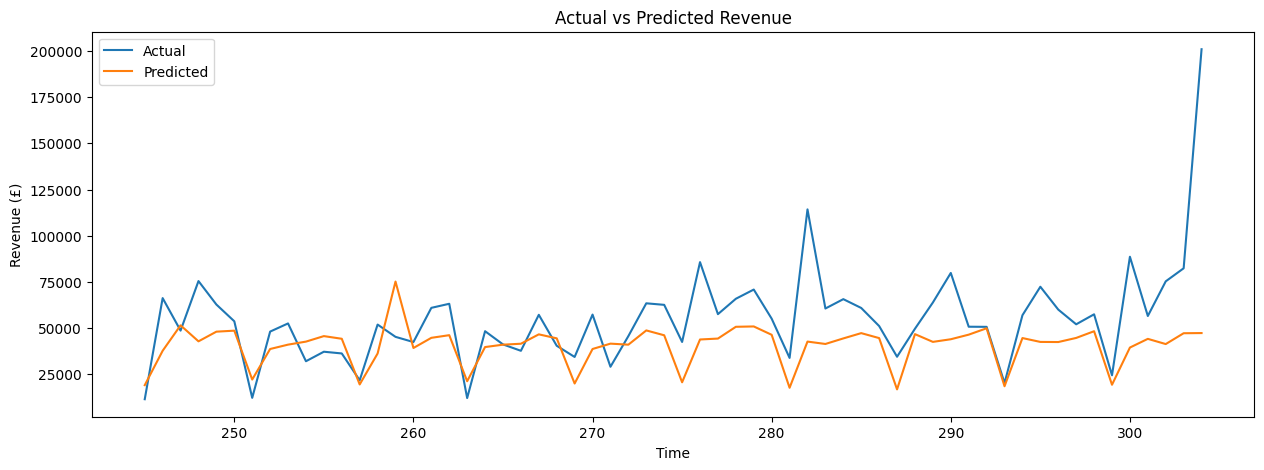

In [80]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual"
)

plt.plot(
    y_test.index,
    predictions,
    label="Predicted"
)

plt.title("Actual vs Predicted Revenue")

plt.xlabel("Time")
plt.ylabel("Revenue (£)")

plt.legend()

plt.show()

# 📊 Mystery Retail Intelligence

## ALGOTHON'26 — ALG-DATA-01

### The Mystery Dataset

---

## 🎯 Project Objective

The objective of this project is to investigate the UCI Online Retail
dataset without a predefined business question and discover meaningful
patterns, relationships, anomalies, customer behaviors, and predictive
insights.

---

## 🔍 Problem Statement

The dataset contains a large number of online retail transactions.
However, no specific business question is provided.

Our solution investigates the dataset systematically through:

- Data cleaning
- Variable understanding
- Exploratory Data Analysis
- Relationship analysis
- Customer segmentation
- Anomaly detection
- Hypothesis testing
- Predictive analysis

---

## 🛠️ Technology Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- OpenPyXL
- Google Colab

---

## 📋 Dataset

Dataset: UCI Online Retail Dataset

The dataset contains online retail transaction information including:

- Invoice Number
- Stock Code
- Product Description
- Quantity
- Invoice Date
- Unit Price
- Customer ID
- Country

A new `Amount` variable is created:

**Amount = Quantity × UnitPrice**

---

## 🧹 Data Cleaning

The following cleaning operations are performed:

1. Remove duplicate records.
2. Handle missing values.
3. Convert InvoiceDate into datetime format.
4. Identify cancelled invoices.
5. Remove cancelled transactions from sales analysis.
6. Remove transactions with invalid quantity.
7. Remove transactions with invalid unit price.
8. Calculate transaction revenue.

---

## 📊 Exploratory Data Analysis

The dataset is explored using:

- Total revenue
- Number of orders
- Number of customers
- Number of products
- Number of countries
- Daily revenue
- Top products
- Top countries

---

## 🔗 Relationship Analysis

Spearman correlation is used to investigate relationships between:

- Quantity
- Unit Price
- Transaction Amount

This helps identify whether unusual relationships exist within
the retail transactions.

---

## 👥 Customer Segmentation

RFM analysis is performed using:

- Recency
- Frequency
- Monetary Value

Customers are categorized into groups such as:

- Champions
- Loyal / Active
- Potential
- At Risk
- Hibernating

---

## 🚨 Anomaly Detection

Isolation Forest is used to identify unusual transactions.

The model considers:

- Quantity
- Unit Price
- Transaction Amount

The detected observations are treated as statistical anomalies
requiring further investigation.

---

## 🧪 Hypotheses

### Hypothesis 1

**Bulk purchases are associated with lower unit prices.**

Spearman correlation and median price comparisons are used to
evaluate this hypothesis.

### Hypothesis 2

**Repeat customers contribute a significant share of identified-customer revenue.**

Customers with multiple orders are compared with one-time customers.

---

## 🔮 Predictive Analysis

A Random Forest Regression model is used to forecast daily revenue.

Features include:

- Previous-day revenue
- Previous-week revenue
- Seven-day rolling revenue
- Day of week
- Month

A chronological train-test split is used to reduce future-data leakage.

---

## 💡 Key Discovery

The main goal is not simply to visualize the dataset.

The goal is to allow the data to reveal meaningful patterns that
were not obvious before analysis.

The strongest discoveries are supported by actual measurements,
visualizations, statistical relationships, and model results.

---

## 🏆 Conclusion

This project transforms an open-ended mystery dataset into an
evidence-driven retail intelligence system.

The complete workflow is:

**Raw Data → Cleaning → Exploration → Relationships → Customer
Segmentation → Anomaly Detection → Hypothesis Testing → Prediction
→ Insights**

---

## 🚀 Future Improvements

- Real-time retail data integration
- Advanced time-series forecasting
- Interactive deployment
- Automated business recommendations
- More advanced customer lifetime value analysis
- Real-time anomaly alerts
